# Tree‑Ring Watermark (Mid‑Step Injection @ t_A) + Fine‑Tuning

In [1]:
import math, os, time, random, json
from typing import Optional, Tuple, Dict, Any
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F, matplotlib.pyplot as plt

try:
    from diffusers import DDPMPipeline, DDPMScheduler

    HAS_DIFFUSERS = True
except Exception:
    HAS_DIFFUSERS = False
    DDPMPipeline = None
    DDPMScheduler = None


class Cfg:
    dataset: str = "CIFAR10"                 # Which dataset the demo uses. Affects t_A choice and channel count.
    model_id = "google/ddpm-cifar10-32"
    image_size: int = 32  # Spatial resolution. Must match the pretrained UNet (here: 32x32).

    sample_steps = 1000
    gamma = 0.8
    seed = 1234
    H = 32
    W = 32
    channels = 3
    wtmk_ch = 0
    tA_ratio = 0.75 # 0.75 for CIFAR, and 0.5 for MNIST and CelebA
    max_steps = 0
    lr = 1e-4
    train_scope = "all"
    verify_batches = 4
    verify_batch_size = 16
    corr_threshold = 0.02
    ring_radius = 15
    lam_clip = 0.02
    f2_scale = 1.0
    alpha = 0.1       
    using_subset: bool = True  # Use a subset of the training data for quick fine-tuning (True) or full set (False).
    subset_size: int = 5000  # How many training images to fine-tune on (paper trains from scratch; we fine-tune briefly).
    batch_size: int = 128    # Larger batches = better signal averaging for the watermark gradient, but use what fits in VRAM.
    num_workers: int = 4     # DataLoader workers; increase if the input pipeline becomes the bottleneck.
    finetune_sweep = [0, 100,  300, 500]  # Ablate fine-tuning steps for verification (e.g. [100,200,300,400]).
cfg = Cfg()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
random.seed(cfg.seed)
H, W, channels, WTMK_CH = cfg.H, cfg.W, cfg.channels, cfg.wtmk_ch
tA = max(1, int(cfg.tA_ratio * cfg.sample_steps))
print(f"Device: {device} | Size: {H}x{W} | steps={cfg.sample_steps} | t_A={tA}")

c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\torch\onnx\_internal\_beartype.py:36: UserWarning: module 'beartype.roar' has no attribute 'BeartypeDecorHintPep585DeprecationWarning'
  warnings.warn(f"{e}")


Device: cuda | Size: 32x32 | steps=1000 | t_A=750


In [2]:
from torchvision import transforms
import torchvision
from torch.utils.data import DataLoader, Subset

if cfg.dataset.upper() == "CIFAR10":
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    ])
    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
    cfg.channels = 3
    tA_frac = cfg.tA_ratio
elif cfg.dataset.upper() == "MNIST":
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,)),
    ])
    trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    cfg.channels = 1
    tA_frac = cfg.tA_ratio
else:
    raise ValueError("Unsupported dataset")

idx = np.random.choice(len(trainset), size=min(cfg.subset_size, len(trainset)), replace=False)
subset = Subset(trainset, idx) if cfg.using_subset else trainset
train_loader = DataLoader(subset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)

Files already downloaded and verified


In [3]:
if not HAS_DIFFUSERS: raise RuntimeError("Install diffusers")
pipe = DDPMPipeline.from_pretrained(cfg.model_id).to(device)
unet: nn.Module = pipe.unet; scheduler: DDPMScheduler = pipe.scheduler
print("Loaded UNet & Scheduler.")


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loaded UNet & Scheduler.


In [4]:
def _to_u8(x01: torch.Tensor) -> torch.Tensor:
    return (x01.clamp(0,1) * 255).to(torch.uint8).cpu()

@torch.no_grad()
def sample_paper(unet_like, scheduler_like, n=36, steps=1000, capture_tA: Optional[int]=None, gamma=0.8):
    unet_like.eval(); scheduler_like.set_timesteps(steps, device=device); timesteps = scheduler_like.timesteps
    x = torch.randn(n, channels, H, W, device=device); x_tA=None; cap_idx=None
    if capture_tA is not None:
        diffs = (timesteps.to(torch.long) - int(capture_tA)).abs(); cap_idx = int(torch.argmin(diffs).item())
    for i, tt in enumerate(timesteps):
        eps = unet_like(x, tt, return_dict=False)[0]
        out = scheduler_like.step(eps, tt, x, return_dict=True); x = out.prev_sample
        if cap_idx is not None and i == cap_idx: x_tA = x.clone()
    x = (x / gamma); x = ((x.clamp(-1,1) + 1)*0.5).detach()
    if x_tA is not None: x_tA = (x_tA / gamma); x_tA = ((x_tA.clamp(-1,1)+1)*0.5).detach()
    return x, x_tA

@torch.no_grad()
def _generate_u8(unet_like, scheduler_like, n: int, steps: int, gamma: float) -> torch.Tensor:
    bs, out, left = min(256, n), [], n
    while left>0:
        cur = min(bs, left); imgs,_ = sample_paper(unet_like, scheduler_like, n=cur, steps=steps, capture_tA=None, gamma=gamma)
        out.append(_to_u8(imgs)); left -= cur
    return torch.cat(out, dim=0)[:n]


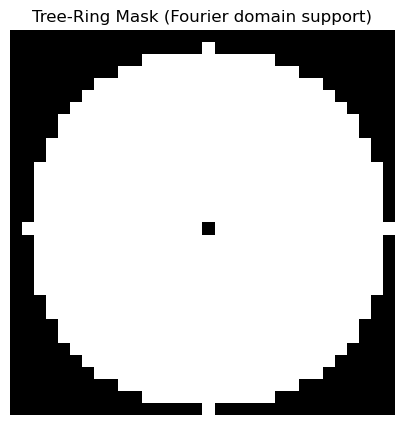

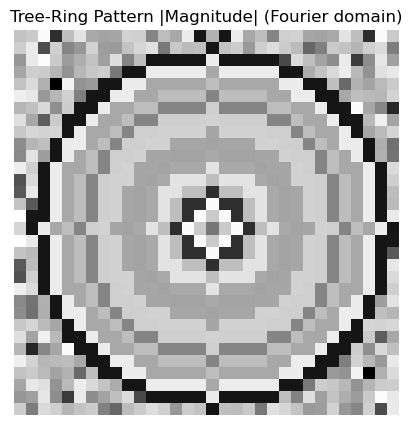

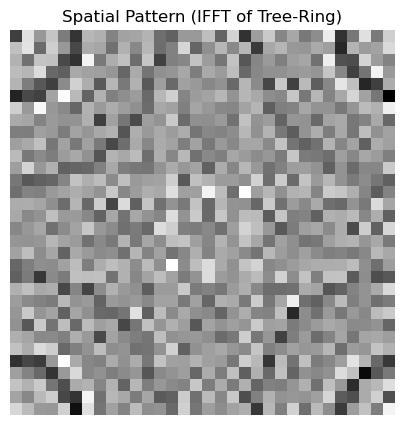

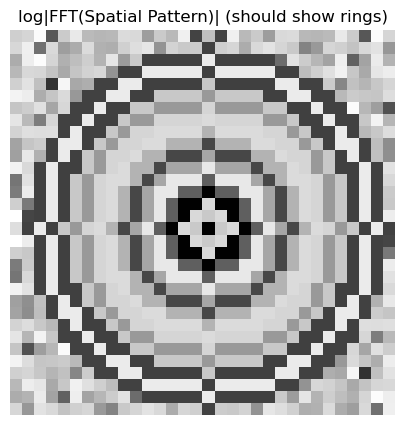

In [5]:
# ---------------------------------------------------------
# Tree-Ring watermark functions
# ---------------------------------------------------------
def build_tree_ring_mask(h: int, w: int, radius: int):
    """
    Build a boolean circular mask (filled disc) with a given radius.
    This is the Tree-Ring paper style — only radius is the hyper-parameter.
    """
    yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    cy, cx = h // 2, w // 2
    rr = np.sqrt((yy - cy)**2 + (xx - cx)**2).astype(np.float32)
    mask = rr <= radius
    mask[cy, cx] = False  # exclude DC component
    return mask


def build_tree_ring_pattern(cfg, device="cuda"):
    """
    Build Tree-Ring watermark pattern following the paper.
    Uses only radius from cfg.ring_params[0][0] if provided, or cfg.H/W otherwise.
    
    Returns:
        ring_mask : [H,W] bool mask
        ring_patt : [H,W] float32 pattern in Fourier domain
    """
    torch.manual_seed(cfg.seed)
    np.random.seed(cfg.seed)

    H, W, C = cfg.H, cfg.W, cfg.channels
    radius = cfg.ring_radius

    # --- base random field ---
    gt_init = torch.randn(1, C, H, W, device=device)
    gt_patch = torch.fft.fftshift(torch.fft.fft2(gt_init), dim=(-1, -2))
    gt_patch_tmp = gt_patch.clone()

    # --- build ring by copying across concentric discs up to radius ---
    for i in range(radius, 0, -1):
        tmp_mask = build_tree_ring_mask(H, W, i)
        tmp_mask = torch.tensor(tmp_mask, device=device, dtype=torch.bool)
        for j in range(gt_patch.shape[1]):
            gt_patch[:, j, tmp_mask] = gt_patch_tmp[0, j, 0, i].item()

    ring_mask = build_tree_ring_mask(H, W, radius)
    ring_patt = gt_patch[0, 0].detach().cpu().numpy()
    return ring_mask, ring_patt

# ---------------------------------------------------------
# Optional Visualization
# ---------------------------------------------------------
def visualize_tree_ring(mask, pattern, cfg):
    """Visualize Tree-Ring pattern in both Fourier and spatial domains."""
    H, W = cfg.H, cfg.W

    def imshow(img, title, cmap="gray", figsize=(5,5)):
        plt.figure(figsize=figsize)
        plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis("off")
        plt.show()

    # Fourier magnitude (log scale)
    patt_mag = np.log1p(np.abs(pattern))
    imshow(mask.astype(float), "Tree-Ring Mask (Fourier domain support)")
    imshow(patt_mag, "Tree-Ring Pattern |Magnitude| (Fourier domain)")

    # Spatial kernel (IFFT)
    spatial = np.fft.ifft2(np.fft.ifftshift(pattern)).real
    spatial = (spatial - spatial.mean()) / (spatial.std() + 1e-6)
    imshow(spatial, "Spatial Pattern (IFFT of Tree-Ring)")

    # FFT of spatial kernel (to confirm ring structure)
    fft_back = np.fft.fftshift(np.fft.fft2(spatial))
    fft_back_mag = np.log1p(np.abs(fft_back))
    imshow(fft_back_mag, "log|FFT(Spatial Pattern)| (should show rings)")

# ---------------------------------------------------------
# Example usage
# ---------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

ring_mask, ring_patt = build_tree_ring_pattern(cfg, device=device)
visualize_tree_ring(ring_mask, ring_patt, cfg)

In [6]:
@torch.no_grad()
def sample_mid_with_tree_ring_injection(unet_like, scheduler_like, ring_mask: np.ndarray, ring_patt: np.ndarray,
                                        n=128, steps=cfg.sample_steps, capture_tA=tA, gamma=cfg.gamma,
                                        lam_clip=0.02, f2_scale: float = 1.0):
    assert ring_mask.shape==(H,W) and ring_patt.shape==(H,W)
    scheduler_like.set_timesteps(steps, device=device); timesteps = scheduler_like.timesteps
    cap_idx = int(torch.argmin((timesteps.to(torch.long) - int(capture_tA)).abs()).item())
    def _spectral_mod_one(x_hw: np.ndarray, lam: float) -> np.ndarray:
        Xi = np.fft.fftshift(np.fft.fft2(x_hw)); mag, ph = np.abs(Xi), np.angle(Xi)
        gain = 1.0 + np.clip(lam, -lam_clip, lam_clip) * ring_patt
        Xi2 = np.fft.ifftshift((mag*gain) * np.exp(1j*ph)); return np.fft.ifft2(Xi2).real.astype(np.float32)
    x = torch.randn(n, channels, H, W, device=device); x_tA=None
    for i,tt in enumerate(timesteps):
        t_idx = int(tt.item())
        if t_idx <= capture_tA:
            lam_t = float((1.0 - cfg.gamma) * f2_scale)
            x_np = x[:, WTMK_CH].detach().cpu().numpy().astype(np.float32)
            for k in range(x_np.shape[0]): x_np[k] = _spectral_mod_one(x_np[k], lam=lam_t)
            x[:, WTMK_CH] = torch.from_numpy(x_np).to(x.device)
        eps = unet_like(x, tt, return_dict=False)[0]
        out = scheduler_like.step(eps, tt, x, return_dict=True); x = out.prev_sample
        if i==cap_idx: x_tA = x.clone()
    x_tA = (x_tA / gamma); x_tA = ((x_tA.clamp(-1,1)+1)*0.5).detach(); return x_tA


c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\diffusers\models\attention_processor.py:2383: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  hidden_states = F.scaled_dot_product_attention(


[Baseline]    spectral correlation: 0.0016
[Watermarked] spectral correlation: 0.5248


C:\Users\mike8\AppData\Local\Temp\ipykernel_2014428\2942317162.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  return float((z*p).mean())


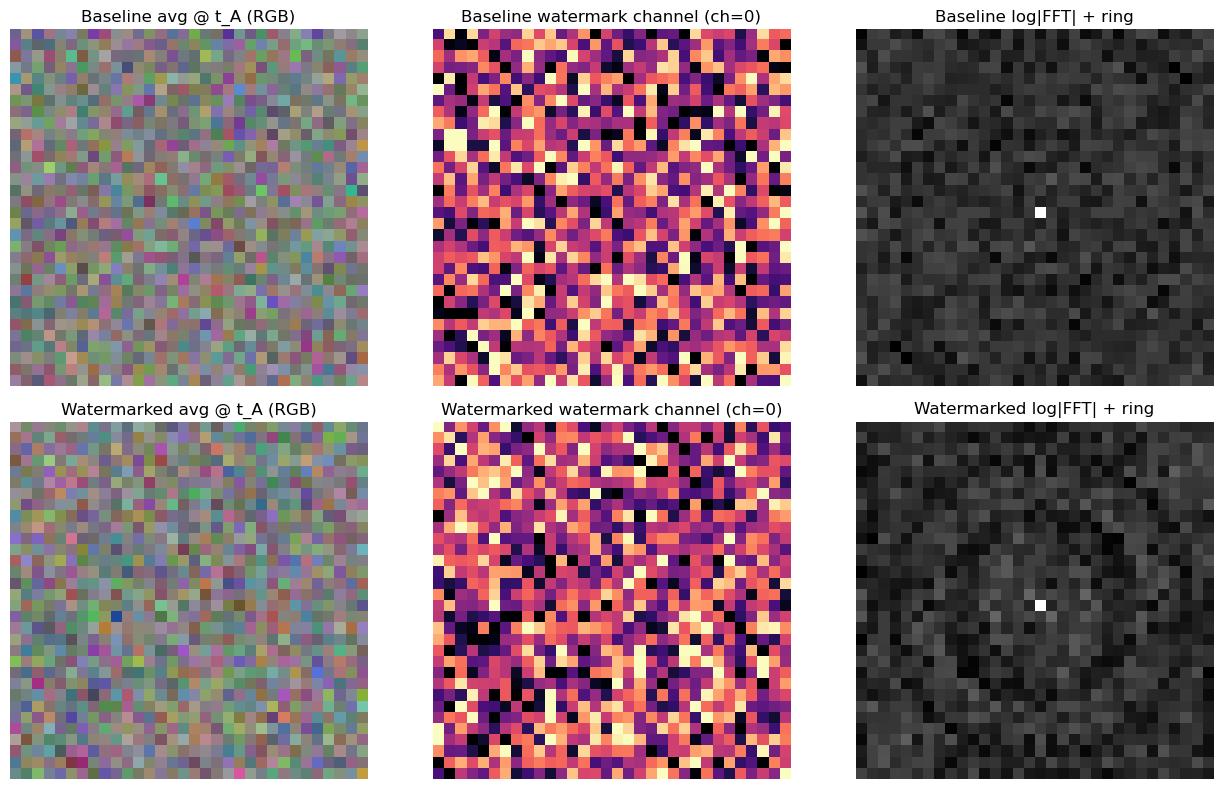

In [7]:
def spectral_correlation_score(x01_chw: torch.Tensor, ring_mask: np.ndarray, ring_patt: np.ndarray) -> float:
    x = x01_chw[WTMK_CH].detach().cpu().numpy().astype(np.float32)
    F = np.fft.fftshift(np.fft.fft2(x)); mag = np.abs(F).astype(np.float32)
    vals = mag[ring_mask]; 
    if vals.size < 16: return 0.0
    z = (vals - vals.mean())/(vals.std()+1e-6)
    p = ring_patt[ring_mask]; p = (p - p.mean())/(p.std()+1e-6) if p.std()>0 else p
    return float((z*p).mean())

def fft_log_with_mask(x01_chw: torch.Tensor, ch: int, ring_mask: np.ndarray):
    x = x01_chw[ch].detach().cpu().numpy().astype(np.float32)
    F = np.fft.fftshift(np.fft.fft2(x)); mag_log = np.log1p(np.abs(F).astype(np.float32))
    edge = np.logical_xor(ring_mask, np.pad(ring_mask, 1)[1:-1,1:-1]); return mag_log, edge

@torch.no_grad()
def visualize_sample_mid_with_tree_ring_injection(unet, scheduler, cfg, seed=None, f2_scale=None):
    """
    Produces a 2x3 figure:
      Row 1: Baseline avg x_{t_A} RGB, watermark channel heatmap, log|FFT| + ring
      Row 2: Watermarked (mid-step injection) same three views
    Prints spectral correlation for both.
    Assumes you already defined: sample_paper, sample_mid_with_tree_ring_injection.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if seed is not None:
        torch.manual_seed(seed); np.random.seed(seed)

    # Build Tree-Ring (Fourier-domain) pattern once
    ring_mask, ring_patt = build_tree_ring_pattern(cfg, device=device)

    # Baseline mid-state @ t_A
    _, xmid_base = sample_paper(
        unet, scheduler,
        n=cfg.verify_batch_size,
        steps=cfg.sample_steps,
        capture_tA=int(cfg.tA_ratio * cfg.sample_steps),
        gamma=cfg.gamma
    )
    xavg_base = xmid_base.mean(dim=0, keepdim=True)  # [1,C,H,W] in [0,1]

    # Watermarked mid-state @ t_A (Tree-Ring injection for t <= t_A)
    xmid_wtmk = sample_mid_with_tree_ring_injection(
        unet, scheduler,
        ring_mask=ring_mask,
        ring_patt=ring_patt,
        n=cfg.verify_batch_size,
        steps=cfg.sample_steps,
        capture_tA=int(cfg.tA_ratio * cfg.sample_steps),
        gamma=cfg.gamma,
        lam_clip=cfg.lam_clip,
        f2_scale=(cfg.f2_scale if f2_scale is None else f2_scale),
    )
    xavg_wtmk = xmid_wtmk.mean(dim=0, keepdim=True)

    # Scores
    s_base = spectral_correlation_score(xavg_base[0], ring_mask, ring_patt)
    s_wtmk = spectral_correlation_score(xavg_wtmk[0], ring_mask, ring_patt)
    print(f"[Baseline]    spectral correlation: {s_base:.4f}")
    print(f"[Watermarked] spectral correlation: {s_wtmk:.4f}")

    # Viz prep
    ch_base = xavg_base[0, cfg.wtmk_ch].cpu().numpy()
    lo_b, hi_b = np.percentile(ch_base, [5, 95])

    ch_wtmk = xavg_wtmk[0, cfg.wtmk_ch].cpu().numpy()
    lo_w, hi_w = np.percentile(ch_wtmk, [5, 95])

    mag_base, edge = fft_log_with_mask(xavg_base[0], cfg.wtmk_ch, ring_mask)
    mag_wtmk, _    = fft_log_with_mask(xavg_wtmk[0], cfg.wtmk_ch, ring_mask)

    # Plot
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))

    # Row 1: Baseline
    axes[0,0].imshow(xavg_base[0].permute(1,2,0).cpu().numpy())
    axes[0,0].set_title("Baseline avg @ t_A (RGB)"); axes[0,0].axis("off")

    im = axes[0,1].imshow(ch_base, cmap="magma", vmin=lo_b, vmax=hi_b)
    axes[0,1].set_title(f"Baseline watermark channel (ch={cfg.wtmk_ch})"); axes[0,1].axis("off")

    axes[0,2].imshow(mag_base, cmap="gray")
    ys, xs = np.where(edge); axes[0,2].plot(xs, ys, '.', ms=0.5, alpha=0.7, color='cyan')
    axes[0,2].set_title("Baseline log|FFT| + ring"); axes[0,2].axis("off")

    # Row 2: Watermarked
    axes[1,0].imshow(xavg_wtmk[0].permute(1,2,0).cpu().numpy())
    axes[1,0].set_title("Watermarked avg @ t_A (RGB)"); axes[1,0].axis("off")

    axes[1,1].imshow(ch_wtmk, cmap="magma", vmin=lo_w, vmax=hi_w)
    axes[1,1].set_title(f"Watermarked watermark channel (ch={cfg.wtmk_ch})"); axes[1,1].axis("off")

    axes[1,2].imshow(mag_wtmk, cmap="gray")
    ys, xs = np.where(edge); axes[1,2].plot(xs, ys, '.', ms=0.5, alpha=0.7, color='cyan')
    axes[1,2].set_title("Watermarked log|FFT| + ring"); axes[1,2].axis("off")

    plt.tight_layout()
    plt.show()
    return {"score_base": s_base, "score_wtmk": s_wtmk, "ring_mask": ring_mask, "ring_patt": ring_patt}

vis_out = visualize_sample_mid_with_tree_ring_injection(unet, scheduler, cfg, seed=cfg.seed)

In [8]:

def set_trainable_params(unet: nn.Module, scope: str = "all"):
    for p in unet.parameters(): p.requires_grad=False
    if scope=="all":
        for p in unet.parameters(): p.requires_grad=True
    elif scope=="last_block":
        for name,p in unet.named_parameters():
            if any(k in name for k in ["down_blocks.3","up_blocks.3","conv_out"]): p.requires_grad=True
    else:
        raise ValueError(scope)

def ddpm_train_step(unet, scheduler, x0, opt):
    """
    One noise-prediction step: x_t = sqrt(alphabar_t) x0 + sqrt(1-alphabar_t) eps, predict eps, MSE loss.
    """
    unet.train()
    device = x0.device
    dtype  = x0.dtype

    # make sure the schedule buffer & the index are on the same device
    alphas_cumprod = scheduler.alphas_cumprod.to(device=device, dtype=dtype)

    bsz = x0.size(0)
    t = torch.randint(
        low=0,
        high=alphas_cumprod.shape[0],
        size=(bsz,),
        device=device,            # index tensor on the same device
        dtype=torch.long,
    )

    noise = torch.randn_like(x0)

    with torch.no_grad():
        alpha_prod_t = alphas_cumprod[t].view(-1, 1, 1, 1)             # safe indexing
        x_t = torch.sqrt(alpha_prod_t) * x0 + torch.sqrt(1 - alpha_prod_t) * noise

    pred = unet(x_t, t, return_dict=False)[0]
    loss = F.mse_loss(pred, noise)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()
    return float(loss.item())

def run_finetune(unet: nn.Module, scheduler: DDPMScheduler, data_loader, max_steps: int, lr: float, train_scope: str = "all"):
    if max_steps<=0: return []
    set_trainable_params(unet, train_scope)
    opt = torch.optim.AdamW([p for p in unet.parameters() if p.requires_grad], lr=lr)
    losses=[]; it=iter(data_loader); t0=time.perf_counter()
    for step in range(1, max_steps+1):
        try: batch = next(it)
        except StopIteration: it=iter(data_loader); batch = next(it)
        x0 = batch[0] if isinstance(batch,(list,tuple)) else (batch["image"] if isinstance(batch,dict) else batch)
        x0 = x0.to(device=next(unet.parameters()).device, dtype=next(unet.parameters()).dtype)
        if x0.min() >= 0 and x0.max() <= 1:
            x0 = x0 * 2 - 1
        loss = ddpm_train_step(unet, scheduler, x0, opt); losses.append(loss)
        if step%50==0 or step==max_steps:
            dt=time.perf_counter()-t0; print(f"[FineTune] {step}/{max_steps} | loss={loss:.4f} | {dt:.1f}s"); t0=time.perf_counter()
    return losses


In [9]:

def finetune_and_report(cfg, max_steps: int):
    # 1) Fine-tune if train_loader provided
    if max_steps>0:
        if "train_loader" not in globals():
            print("[warn] train_loader not defined; skip fine-tune."); loss_traj=[]
        else:
            print(f"[run] Fine-tuning for {max_steps} steps...")
            loss_traj = run_finetune(unet, scheduler, train_loader, max_steps, cfg.lr, cfg.train_scope)
    else:
        loss_traj = []

    # 2) Build ring pattern locally
    ring_mask, ring_patt = build_tree_ring_pattern(cfg, device)

    # 3) Baseline / watermarked @ t_A
    xmid_base = sample_paper(unet, scheduler, n=cfg.verify_batch_size, steps=cfg.sample_steps, capture_tA=tA, gamma=cfg.gamma)[1]
    xavg_base = xmid_base.mean(dim=0, keepdim=True)

    xmid_wtmk = sample_mid_with_tree_ring_injection(unet, scheduler, ring_mask, ring_patt,
                                                    n=cfg.verify_batch_size, steps=cfg.sample_steps,
                                                    capture_tA=tA, gamma=cfg.gamma,
                                                    lam_clip=cfg.lam_clip, f2_scale=cfg.f2_scale)
    xavg_wtmk = xmid_wtmk.mean(dim=0, keepdim=True)

    # 4) Scores
    score_base = spectral_correlation_score(xavg_base[0], ring_mask, ring_patt)
    score_wtmk = spectral_correlation_score(xavg_wtmk[0], ring_mask, ring_patt)

    # 5) Verification batches
    scores=[]
    for _ in range(cfg.verify_batches):
        xmid = sample_mid_with_tree_ring_injection(unet, scheduler, ring_mask, ring_patt,
                                                   n=cfg.verify_batch_size, steps=cfg.sample_steps,
                                                   capture_tA=tA, gamma=cfg.gamma,
                                                   lam_clip=cfg.lam_clip, f2_scale=cfg.f2_scale)
        xavg = xmid.mean(dim=0, keepdim=True)
        s = spectral_correlation_score(xavg[0], ring_mask, ring_patt); scores.append(s)
    scores = np.array(scores, dtype=np.float32)
    success = float((scores >= cfg.corr_threshold).mean())

    # 6) Viz
    fig, axes = plt.subplots(1,3, figsize=(12,4))
    axes[0].imshow(xavg_base[0].permute(1,2,0).cpu().numpy()); axes[0].set_title("Baseline avg @ t_A"); axes[0].axis("off")
    axes[1].imshow(xavg_wtmk[0].permute(1,2,0).cpu().numpy()); axes[1].set_title("Watermarked avg @ t_A"); axes[1].axis("off")
    mag, edge = fft_log_with_mask(xavg_wtmk[0], WTMK_CH, ring_mask)
    axes[2].imshow(mag, cmap="gray"); ys,xs=np.where(edge); axes[2].plot(xs,ys,'.',ms=0.5,alpha=0.6,color='cyan')
    axes[2].set_title("log|FFT| + ring mask"); axes[2].axis("off"); plt.tight_layout(); plt.show()

    return {
        "max_steps": max_steps, "loss_traj": loss_traj,
        "score_base": float(score_base), "score_wtmk": float(score_wtmk),
        "verify_scores": scores.tolist(), "verify_success": success,
        "tA": tA, "ring_params": cfg.ring_radius
    }, fig


=== Running fine-tune sweep: [0, 100, 300, 500] (train_scope='all') ===

--- [1/4] finetune_and_report(max_steps=0) ---


C:\Users\mike8\AppData\Local\Temp\ipykernel_2014428\2942317162.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  return float((z*p).mean())


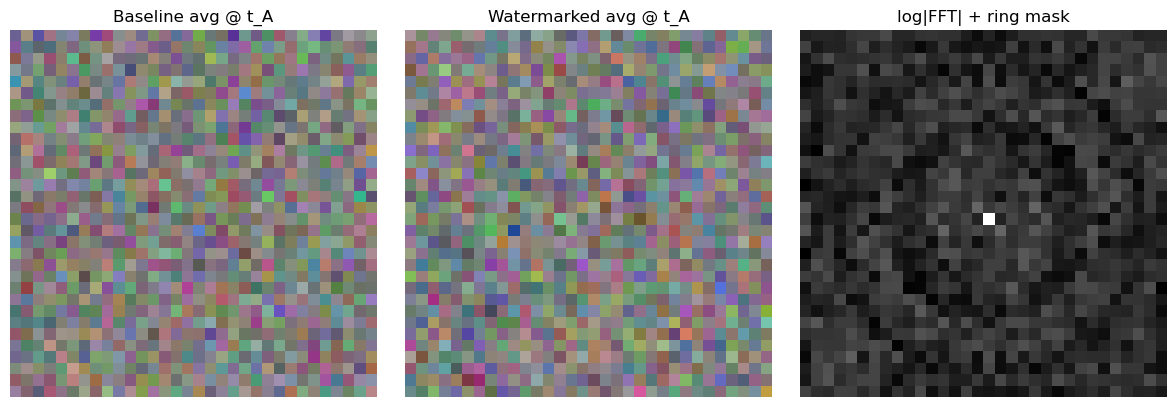

[saved] ./runs_tree_ring_sweep_20251009-122018\summary_steps_0.png

--- [2/4] finetune_and_report(max_steps=100) ---
[run] Fine-tuning for 100 steps...
[FineTune] 50/100 | loss=0.0219 | 18.6s
[FineTune] 100/100 | loss=0.0239 | 18.1s


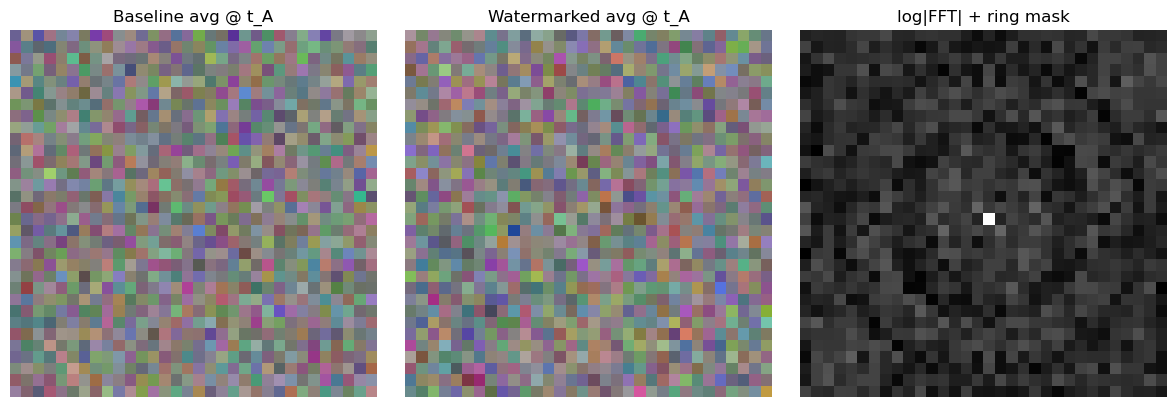

[saved] ./runs_tree_ring_sweep_20251009-122018\summary_steps_100.png

--- [3/4] finetune_and_report(max_steps=300) ---
[run] Fine-tuning for 300 steps...
[FineTune] 50/300 | loss=0.0212 | 17.5s
[FineTune] 100/300 | loss=0.0238 | 18.1s
[FineTune] 150/300 | loss=0.0265 | 18.4s
[FineTune] 200/300 | loss=0.0109 | 18.6s
[FineTune] 250/300 | loss=0.0266 | 27.4s
[FineTune] 300/300 | loss=0.0293 | 18.5s


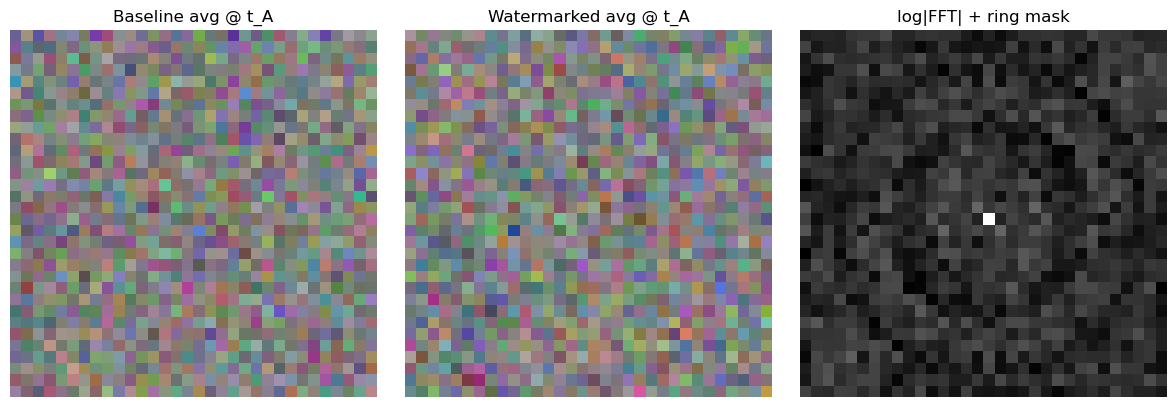

[saved] ./runs_tree_ring_sweep_20251009-122018\summary_steps_300.png

--- [4/4] finetune_and_report(max_steps=500) ---
[run] Fine-tuning for 500 steps...
[FineTune] 50/500 | loss=0.0205 | 18.5s
[FineTune] 100/500 | loss=0.0230 | 17.3s
[FineTune] 150/500 | loss=0.0257 | 17.9s
[FineTune] 200/500 | loss=0.0086 | 18.2s
[FineTune] 250/500 | loss=0.0259 | 28.6s
[FineTune] 300/500 | loss=0.0292 | 17.8s
[FineTune] 350/500 | loss=0.0292 | 18.2s
[FineTune] 400/500 | loss=0.0366 | 17.9s
[FineTune] 450/500 | loss=0.0258 | 29.0s
[FineTune] 500/500 | loss=0.0182 | 18.5s


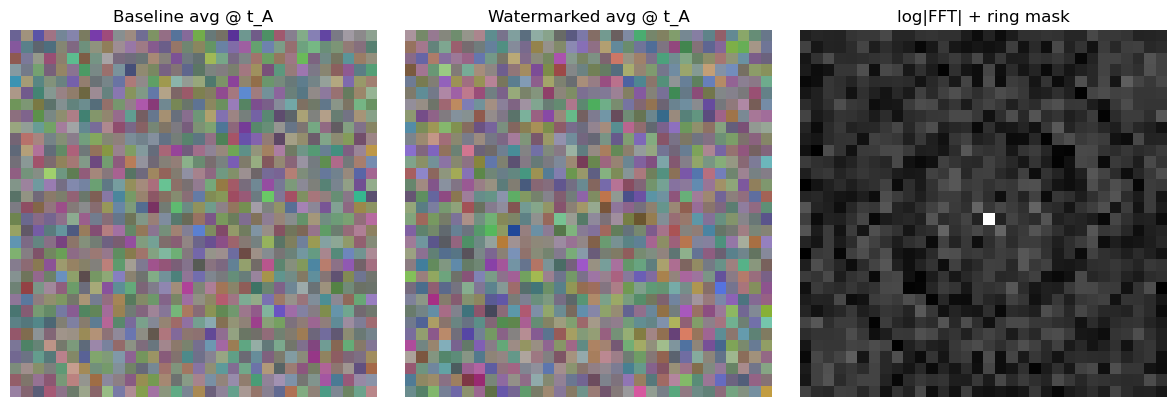

[saved] ./runs_tree_ring_sweep_20251009-122018\summary_steps_500.png

[saved] ./runs_tree_ring_sweep_20251009-122018\results.jsonl


,max_steps,score_base,score_wtmk,verify_success,verify_scores_mean,loss_last,tA,ring_params
0,0,0.001623,0.524793,1.0,0.512750,NaN,750,15
1,100,0.000696,0.525785,1.0,0.513371,0.023940,750,15
2,300,0.001627,0.526621,1.0,0.512907,0.029325,750,15
3,500,0.001228,0.525976,1.0,0.513787,0.018182,750,15



=== Sweep done in 747.8s; outputs @ ./runs_tree_ring_sweep_20251009-122018 ===


In [10]:
# ---------- Fine-tune sweep runner ----------
# Requirements: your `cfg` object and `finetune_and_report(...)` already defined.

import json, os, time
from datetime import datetime

try:
    import pandas as pd
    HAVE_PD = True
except Exception:
    HAVE_PD = False

# 1) Define your sweep (override or add to cfg)
#    Example: no FT (0), brief FT (100, 200), longer FT (400)
cfg.finetune_sweep = getattr(cfg, "finetune_sweep", [0, 100, 200, 400])

# 2) Output folder (optional)
RUN_TAG = datetime.now().strftime("%Y%m%d-%H%M%S")
OUT_DIR = f"./runs_tree_ring_sweep_{RUN_TAG}"
os.makedirs(OUT_DIR, exist_ok=True)

# 3) Run the sweep
all_results = []
fig_paths = []

print(f"=== Running fine-tune sweep: {cfg.finetune_sweep} (train_scope='{cfg.train_scope}') ===")
t0 = time.perf_counter()

for i, steps in enumerate(cfg.finetune_sweep, start=1):
    print(f"\n--- [{i}/{len(cfg.finetune_sweep)}] finetune_and_report(max_steps={steps}) ---")
    # keep cfg.max_steps in sync (in case your code reads it elsewhere)
    cfg.max_steps = steps

    # Call your existing function (uses Tree-Ring mid-injection/detection internally)
    res, fig = finetune_and_report(
        cfg,
        max_steps=steps,
        # you can pass/override any of the optional args here if needed:
        # ring_params=cfg.ring_params,
        # verify_batches=cfg.verify_batches,
        # verify_batch_size=cfg.verify_batch_size,
        # corr_threshold=cfg.corr_threshold,
    )

    # Save a figure (if provided)
    fig_file = os.path.join(OUT_DIR, f"summary_steps_{steps}.png")
    try:
        if fig is not None:
            fig.savefig(fig_file, dpi=150, bbox_inches="tight")
            fig_paths.append(fig_file)
            print(f"[saved] {fig_file}")
    except Exception as e:
        print(f"[warn] could not save figure for steps={steps}: {e}")

    # Keep a compact summary row
    row = {
        "max_steps":            res.get("max_steps", steps),
        "score_base":           res.get("score_base"),
        "score_wtmk":           res.get("score_wtmk"),
        "verify_success":       res.get("verify_success"),
        "verify_scores_mean":   (sum(res.get("verify_scores", []))/max(1, len(res.get("verify_scores", []))) if isinstance(res.get("verify_scores"), list) else None),
        "loss_last":            (res["loss_traj"][-1] if isinstance(res.get("loss_traj"), list) and res["loss_traj"] else None),
        "ring_params":          res.get("ring_params"),
        "tA":                   res.get("tA"),
    }
    all_results.append(row)

# 4) Save results to disk
results_jsonl = os.path.join(OUT_DIR, "results.jsonl")
with open(results_jsonl, "w") as f:
    for r in all_results:
        f.write(json.dumps(r) + "\n")
print(f"\n[saved] {results_jsonl}")

# 5) Pretty print / DataFrame
if HAVE_PD:
    import pandas as pd
    df = pd.DataFrame(all_results)
    # common columns you probably care about:
    cols = ["max_steps", "score_base", "score_wtmk", "verify_success", "verify_scores_mean", "loss_last", "tA", "ring_params"]
    cols = [c for c in cols if c in df.columns]
    display(df[cols].sort_values("max_steps"))
else:
    print("\nSweep summary:")
    for r in sorted(all_results, key=lambda x: x["max_steps"]):
        print(r)

print(f"\n=== Sweep done in {time.perf_counter() - t0:.1f}s; outputs @ {OUT_DIR} ===")